In [3]:
!pip install pylatexenc
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 85.8 MB/s eta 0:00:00


In [15]:
# 1. 라이브러리 불러오기
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter
import numpy as np
import matplotlib.pyplot as plt


In [16]:
# ============================================================
# 2. 회로 구현
# ============================================================

# 1) 파라미터 정의
theta_A = Parameter('θA')   # Feature A
theta_B = Parameter('θB')   # Feature B

# 2 qubit, 2 classical bit
qc = QuantumCircuit(2, 2)


# 2) Angle Encoding
qc.ry(theta_A, 0)   # q0에 Feature A 인코딩
qc.ry(theta_B, 1)   # q1에 Feature B 인코딩


# 3) Entanglement
qc.h(0)
qc.cx(0, 1)


# 4) Measurement
qc.measure(0, 0)
qc.measure(1, 1)



In [19]:
# ============================================================
# 3. 회로 확인
# ============================================================

print(qc.draw())


     ┌────────┐┌───┐     ┌─┐   
q_0: ┤ Ry(θA) ├┤ H ├──■──┤M├───
     ├────────┤└───┘┌─┴─┐└╥┘┌─┐
q_1: ┤ Ry(θB) ├─────┤ X ├─╫─┤M├
     └────────┘     └───┘ ║ └╥┘
c: 2/═════════════════════╩══╩═
                          0  1 


In [20]:
# ============================================================
# 4. Feature 값 설정
# ============================================================

# 예제 Feature 값
feature_A = np.pi / 4
feature_B = np.pi / 3

# Parameter에 실제 값 할당
bound_qc = qc.assign_parameters({
    theta_A: feature_A,
    theta_B: feature_B
})



In [22]:
# ============================================================
# 5. 회로 실행
# ============================================================

backend = AerSimulator()

compiled_qc = transpile(
    bound_qc,
    backend
)

job = backend.run(
    compiled_qc,
    shots=1024
)

result = job.result()

counts = result.get_counts()



측정 결과:


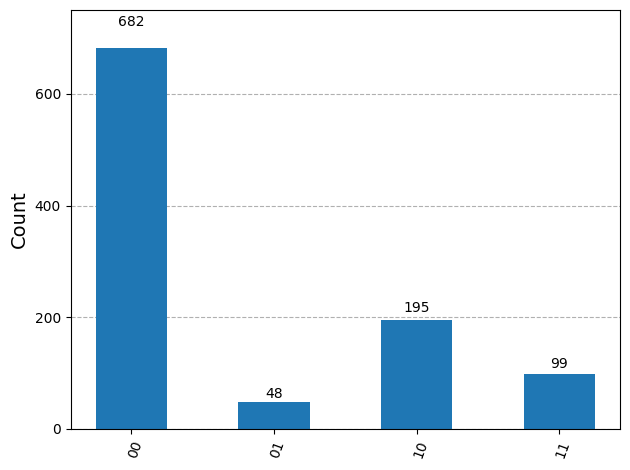

In [25]:
# ============================================================
# 6. 결과 확인
# ============================================================

print("측정 결과:")
fig = plot_histogram(counts)
display(fig)


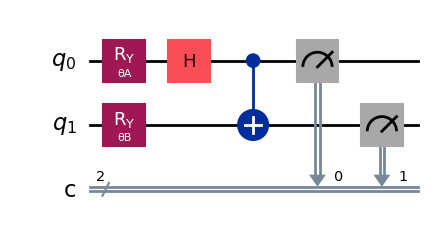

In [26]:
# ============================================================
# 7. 측정 결과 시각화
# ============================================================

from matplotlib import pyplot as plt

qc.draw("mpl")